# Lab2: Errors and generalization

In this lab, we explore the theoretical foundations of Machine Learning generalization. We will start with classical bounds (VC-dimension), move to data-dependent measures (Rademacher Complexity) on linear models, and finally introduce Deep Neural Networks to see where classical theory breaks down (The Memorization Paradox) and how modern phenomena emerge (Double Descent, Scaling Laws).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# for reproducibility
np.random.seed(42)

def generate_data(n_samples=2000, n_features=50, noise=0.5):
    X = np.random.randn(n_samples, n_features)
    true_w = np.random.randn(n_features)
    y = X.dot(true_w) + np.random.randn(n_samples) * noise
    return train_test_split(X, y, test_size=0.15, random_state=42)

X_train, X_test, y_train, y_test = generate_data()
print(f'Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}')

Training samples: 1700, Test samples: 300


## VC-dimension

Classical statistical learning theory attempts to bound generalization error by measuring the "capacity" of a hypothesis class $\mathcal{H}$, regardless of the data distribution. Vapnik and Chevronenski (1971) defined the so-called VC-dimension, $VC(\mathcal{H})$, that quantifies the maximum number of data points that the model can *shatter*. By this, we mean that the model can perfectly classify all possible $2^n$ binary label combinations. 

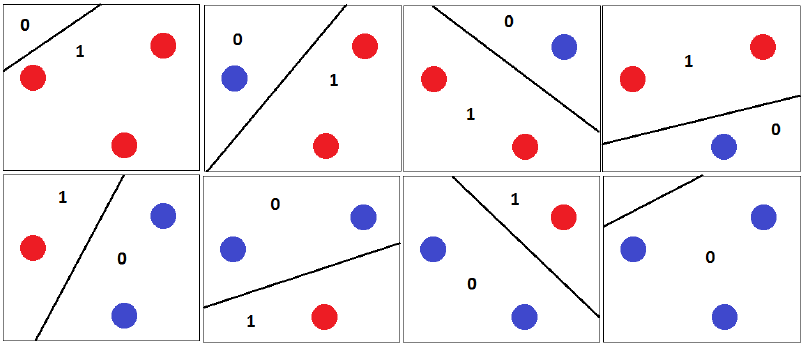

The generalization bound that we can find using VC-dimension $VC(\mathcal{H})$ states that with probability at least $1-\delta$:
$$
R(h) \leq \hat{R}_S(h) + O\left(\sqrt{\frac{VC(\mathcal{H}) \log(n/VC(\mathcal{H})) + \log(1/\delta)}{n}}\right)
$$

where $n$ is the number of data samples, $\hat{R}_S(h)$ is the empirical risk and $R(h)$ is the true risk.

In [2]:
def get_vc_dim_linear(d):
    """
    For a linear hypothesis class in d dimensions, 
    the VC dimension (or Pseudo-dimension for regression) is d + 1.
    """
    return d + 1

**if you get bored easily:** try to prove it!

In [ ]:
def vc_generalization_bound(train_error, vc_dim, n, delta=0.05):
    """
    TODO: Complete this function to calculate the VC generalization bound.
    Formula: R(h) <= R_hat(h) + sqrt((VC(H) * (log(n/VC(H)) + 1) + log(1/delta)) / n)
    """
    complexity_term = (vc_dim * (np.log(n/vc_dim) + 1) + np.log(1/delta)) / n
 
    R_h = train_error + np.sqrt(complexity_term)
    return R_h
    


Now let's check how this work. We will fit a linear model on our dummy data and compute the **empirical risk**, the **VC-dimension** and the **test error bound** induced by the VC-dimension.

In [4]:
# Testing VC on Linear Regression
lin_mod = LinearRegression().fit(X_train, y_train)
train_err_lin = mean_squared_error(y_train, lin_mod.predict(X_train))
test_err_lin = mean_squared_error(y_test, lin_mod.predict(X_test))
vc_dim_lin = get_vc_dim_linear(X_train.shape[1])

# TODO: Call your function
vc_bound = vc_generalization_bound(train_err_lin, vc_dim_lin, X_train.shape[0])

print(f"{'='*45}")
print(f"LINEAR REGRESSION: VC GENERALIZATION BOUND")
print(f"{'='*45}")
print(f"Empirical Risk (Train MSE):      {train_err_lin:.4f}")
print(f"Actual Risk (Test MSE):         {test_err_lin:.4f}")
print(f"VC Dimension (Capacity):        {vc_dim_lin}")
print(f"Theoretical Bound (Ceiling):    {vc_bound:.4f}")

LINEAR REGRESSION: VC GENERALIZATION BOUND
Empirical Risk (Train MSE):      0.2416
Actual Risk (Test MSE):         0.2422
VC Dimension (Capacity):        51
Theoretical Bound (Ceiling):    0.6117


Practically speaking, this means: "I don't know exactly what the test error will be, but I can guarantee with 95% confidence that it will be **lower** than this number".

In [5]:
# 5. Calculate Actual Test Error (To show the gap)
test_err_lin = mean_squared_error(y_test, lin_mod.predict(X_test))

print(f"{'='*45}")
print(f"Generalization Gap (VC-Theory): {vc_bound - train_err_lin:.4f}")
print(f"Generalization Gap (Actual):    {test_err_lin - train_err_lin:.4f}")
print(f"{'='*45}")

Generalization Gap (VC-Theory): 0.3701
Generalization Gap (Actual):    0.0006


## Rademacher Complexity

**Rademacher Complexity** (Bartlett and Mendelson, 2002) measures how well a model can fit pure random noise (Rademacher variables $\sigma_i \in \{-1, +1\}$) on our specific dataset $D$ of size $m$:

$$\hat{\mathfrak{R}}_D(\mathcal{H}) = \mathbb{E}_\sigma \left[ \sup_{h \in \mathcal{H}} \frac{1}{m} \sum_{i=1}^m \sigma_i h(x_i) \right]$$

The new, much tighter generalization bound is:
$$R(h) \leq \hat{R}_D(h) + 2\hat{\mathfrak{R}}_D(\mathcal{H}) + 3\sqrt{\frac{\log(2/\delta)}{2m}}$$

Because computing the exact expectation ($\mathbb{E}_\sigma$) over all possible noise vectors is intractable, we approximate it using Monte Carlo sampling.

In [6]:
def empirical_rademacher_complexity(model_class, model_kwargs, X, n_iterations=10):
    """
    Monte Carlo approximation of the Empirical Rademacher Complexity.
    Measures the capacity of the hypothesis class to fit random noise.
    """
    n_samples = X.shape[0]
    rademacher_vals = []
    
    for _ in range(n_iterations):
        # TODO 1: Generate random Rademacher variables sigma_i sampled from {-1, 1}
        # Hint: use np.random.choice(...)
        
        sigma = None 
        sigma = np.random.choice([-1, 1], size=n_samples)
        # TODO 2: Initialize the model (using model_class and **model_kwargs) 
        # and train it (.fit) on data X using 'sigma' as target labels.
        # This approximates the supremum: finding the function h in H that maximizes the correlation.
        model = model_class(**model_kwargs)
        model.fit(X, sigma)
        
        # TODO 3: Get the model's predictions on X. 
        # Since we are simulating a binary classification problem {-1, 1},
        # use np.sign() to extract only the sign of the continuous predictions.
        preds = np.sign(model.predict(X))
        
        # TODO 4: Calculate the empirical correlation between the random labels (sigma) and the predictions.
        # It is defined as the mean of the element-wise product: mean(sigma_i * pred_i)
        # Append the result to the 'rademacher_vals' list.
        correlation = np.mean(sigma * preds)
        rademacher_vals.append(correlation)

    # TODO 5: Return the expected value (the mean) of the computed correlations across all iterations.
    return np.mean(rademacher_vals)

def rademacher_generalization_bound(train_error, rad_comp, n, delta=0.05):
    """
    Implementation of the Bartlett et al. (2002) generalization bound.
    Formula: R(h) <= R_hat(h) + 2*Rad(H) + 3 * sqrt(ln(2/delta) / (2n))
    """
    # TODO 6: Calculate the penalty term associated with complexity and confidence.
    # Use rad_comp for Rad(H), n for the number of samples, and delta for the probability.
    # Hint: use np.log() for the natural logarithm and np.sqrt() for the square root.
    penalty = 2 * rad_comp + 3 * np.sqrt(np.log(2/delta) / (2*n))
    
    # TODO 7: Return the complete bound (Training Error + Penalty)
    return train_error + penalty

In [8]:
# Testing Rademacher on Linear Regression
rad_linear = empirical_rademacher_complexity(LinearRegression, {}, X_train)
rad_bound = rademacher_generalization_bound(train_err_lin, rad_linear, X_train.shape[0])

print(f"\n{'='*45}")
print(f"LINEAR REGRESSION: RADEMACHER BOUND")
print(f"{'='*45}")
print(f"Empirical Rademacher Complexity: {rad_linear:.4f}")
print(f"Rademacher Bound:                {rad_bound:.4f}")
print(f"VC Bound (Ref):                  {vc_bound:.4f}")


LINEAR REGRESSION: RADEMACHER BOUND
Empirical Rademacher Complexity: 0.1296
Rademacher Bound:                0.5997
VC Bound (Ref):                  0.6117


The VC-dimension is blind: it only counts parameters and it doesn't care if your model is regularized or if your data is easy.
It computes a penalty based on the *maximum potential* of the architecture, regardless on how difficult is to fit *that* data.

Rademacher complexity, instead, actually tests the model by asking: "If I give you pure random noise, how much of it can you actually absorb?" 

Even in a standard Linear Regression, the model's ability to fit noise on a specific set of points $X$ is often lower than the theoretical "shattering" limit assumed by VC theory.

## The Memorization Paradox

Classical theory suggests that to prevent overfitting, we must restrict model capacity. Classical theory dictates that "simpler is better."

Mathematically, this was expressed as the need to keep the VC-dimension $VC(\mathcal{H})$ lower than the number of samples $n$. 

If $VC(\mathcal{H})$ is greater than $n$, the hypothesis class is rich enough to shatter the dataset, and classical bounds become vacuous. In that regime, empirical risk minimization alone does not guarantee generalization, since the model can perfectly fit (or “memorize”) the training data without any worst-case performance guarantees.

However, the paper *"Understanding Deep Learning Requires Rethinking Generalization" (Zhang et al., 2016)* proved that Neural Networks have enough capacity to perfectly fit pure random noise (reaching $\hat{\mathfrak{R}}_D \approx 1$).

Let's see this by transitioning from our Linear model to Deep MLPs.

Linear             | Rademacher Complexity: 0.1359
MLP (8 units)      | Rademacher Complexity: 0.5229
MLP (16 units)     | Rademacher Complexity: 0.7418
MLP (32 units)     | Rademacher Complexity: 0.9906
MLP (64 units)     | Rademacher Complexity: 1.0000
MLP (128 units)    | Rademacher Complexity: 1.0000
MLP (256 units)    | Rademacher Complexity: 1.0000
MLP (512 units)    | Rademacher Complexity: 1.0000
MLP (1024 units)   | Rademacher Complexity: 1.0000


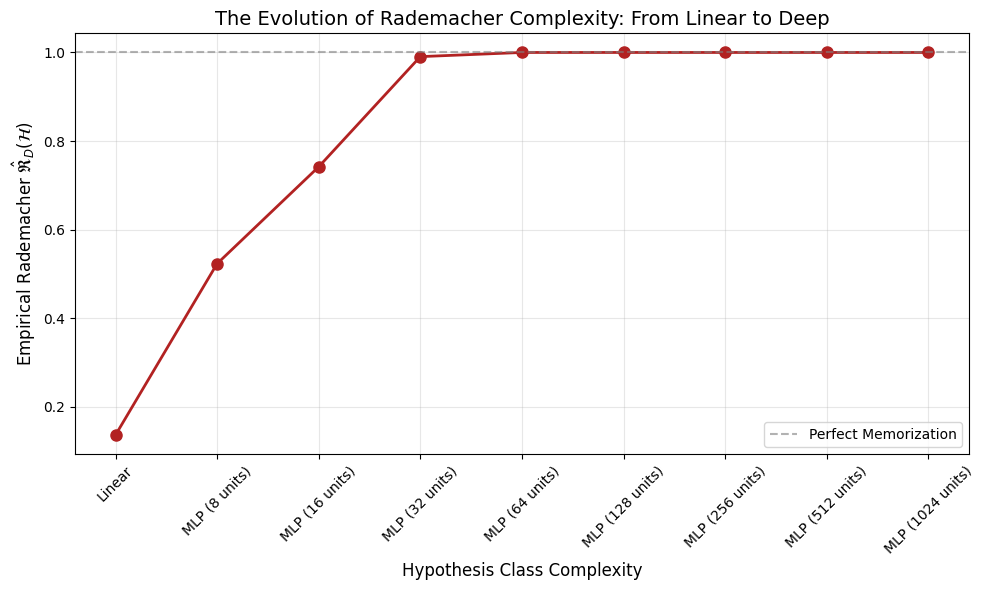

In [9]:
architectures = [
    ('Linear', LinearRegression, {}),
    ('MLP (8 units)', MLPRegressor, {'hidden_layer_sizes': (8,), 'max_iter': 500, 'random_state': 42}), # defaults to ReLU
    ('MLP (16 units)', MLPRegressor, {'hidden_layer_sizes': (16,), 'max_iter': 500, 'random_state': 42}),
    ('MLP (32 units)', MLPRegressor, {'hidden_layer_sizes': (32,), 'max_iter': 500, 'random_state': 42}),
    ('MLP (64 units)', MLPRegressor, {'hidden_layer_sizes': (64,), 'max_iter': 500, 'random_state': 42}),
    ('MLP (128 units)', MLPRegressor, {'hidden_layer_sizes': (128,), 'max_iter': 500, 'random_state': 42}),
    ('MLP (256 units)', MLPRegressor, {'hidden_layer_sizes': (256,), 'max_iter': 1000, 'random_state': 42}),
    ('MLP (512 units)', MLPRegressor, {'hidden_layer_sizes': (512,), 'max_iter': 1000, 'random_state': 42}),
    ('MLP (1024 units)', MLPRegressor, {'hidden_layer_sizes': (1024,), 'max_iter': 1000, 'random_state': 42}),
]

rad_results = []
for name, mod_class, kwargs in architectures:
    # We use 2-3 iterations for speed, as DNNs are computationally expensive
    rad = empirical_rademacher_complexity(mod_class, kwargs, X_train, n_iterations=2)
    rad_results.append(rad)
    print(f'{name: <18} | Rademacher Complexity: {rad:.4f}')

# Plotting the transition
plt.figure(figsize=(10, 6))
labels = [a[0] for a in architectures]
plt.plot(labels, rad_results, marker='o', linestyle='-', color='firebrick', linewidth=2, markersize=8)

# Adding a reference line for perfect memorization
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.6, label='Perfect Memorization')

plt.title('The Evolution of Rademacher Complexity: From Linear to Deep', fontsize=14)
plt.ylabel('Empirical Rademacher $\hat{\mathfrak{R}}_D(\mathcal{H})$', fontsize=12)
plt.xlabel('Hypothesis Class Complexity', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Note:** for deep MLPs, $VC \approx \text{number of weights}$, thus it will be useless to consider VC error bounds for this scenario.

If the classical theory is correct, we expect to observe that models able to fit perfectly random noise exhibit poor generalization abilities. 
This means that if we train these architectures on a set of data and test them on a bunch of unseen items, the more rigid architectures (this reads as: *the ones with lower Rademacher complexity*) should produce lower test errors.

In [10]:
# Architectures pushed towards over-parameterization
architectures = [
    ('Linear', LinearRegression, {}),
    ('MLP (8 units)', MLPRegressor, {'hidden_layer_sizes': (8,), 'max_iter': 500, 'random_state': 42}), # defaults to ReLU
    ('MLP (16 units)', MLPRegressor, {'hidden_layer_sizes': (16,), 'max_iter': 500, 'random_state': 42}),
    ('MLP (32 units)', MLPRegressor, {'hidden_layer_sizes': (32,), 'max_iter': 500, 'random_state': 42}),
    ('MLP (64 units)', MLPRegressor, {'hidden_layer_sizes': (64,), 'max_iter': 500, 'random_state': 42}),
    ('MLP (128 units)', MLPRegressor, {'hidden_layer_sizes': (128,), 'max_iter': 500, 'random_state': 42}),
    ('MLP (256 units)', MLPRegressor, {'hidden_layer_sizes': (256,), 'max_iter': 1000, 'random_state': 42}),
    ('MLP (512 units)', MLPRegressor, {'hidden_layer_sizes': (512,), 'max_iter': 1000, 'random_state': 42}),
    ('MLP (1024 units)', MLPRegressor, {'hidden_layer_sizes': (1024,), 'max_iter': 1000, 'random_state': 42}),
]

train_errors_d = []
test_errors_d = []
labels_d = [a[0] for a in architectures]

print(f"{'Architecture':<20} | {'Train MSE':<10} | {'Test MSE':<10}")
print("-" * 45)

for name, mod_class, kwargs in architectures:
    
    # TODO 1: Initialize the model using the provided class (mod_class) 
    # and unpack the dictionary of keyword arguments (**kwargs).
    model = mod_class(**kwargs)
    
    # TODO 2: If the model is an MLP (hint: check the 'name' string), 
    # use model.set_params() to set 'early_stopping=True' and 'validation_fraction=0.1'.
    # This allows large networks to naturally halt before massively overfitting the noise.
    if 'MLP' in name:
        model.set_params(early_stopping=True, validation_fraction=0.1)
    
    # TODO 3: Fit the model on the training data (X_train, y_train)
    model.fit(X_train, y_train)
    
    # TODO 4: Calculate the Mean Squared Error (MSE) for both training and test sets.
    # Hint: Use the mean_squared_error() function from scikit-learn.
    tr_err = mean_squared_error(y_train, model.predict(X_train))
    te_err = mean_squared_error(y_test, model.predict(X_test))


    # Append the results to our lists
    if tr_err is not None and te_err is not None:
        train_errors_d.append(tr_err)
        test_errors_d.append(te_err)
        print(f"{name:<20} | {tr_err:10.4f} | {te_err:10.4f}")
    else:
        print(f"{name:<20} | NOT IMPLEMENTED")

Architecture         | Train MSE  | Test MSE  
---------------------------------------------
Linear               |     0.2416 |     0.2422
MLP (8 units)        |     0.5875 |     0.9729
MLP (16 units)       |     0.4648 |     0.7923
MLP (32 units)       |     0.3946 |     0.7533
MLP (64 units)       |     0.3066 |     0.6322
MLP (128 units)      |     0.2467 |     0.4905
MLP (256 units)      |     0.1563 |     0.3990
MLP (512 units)      |     0.1625 |     0.4344
MLP (1024 units)     |     0.1456 |     0.3884


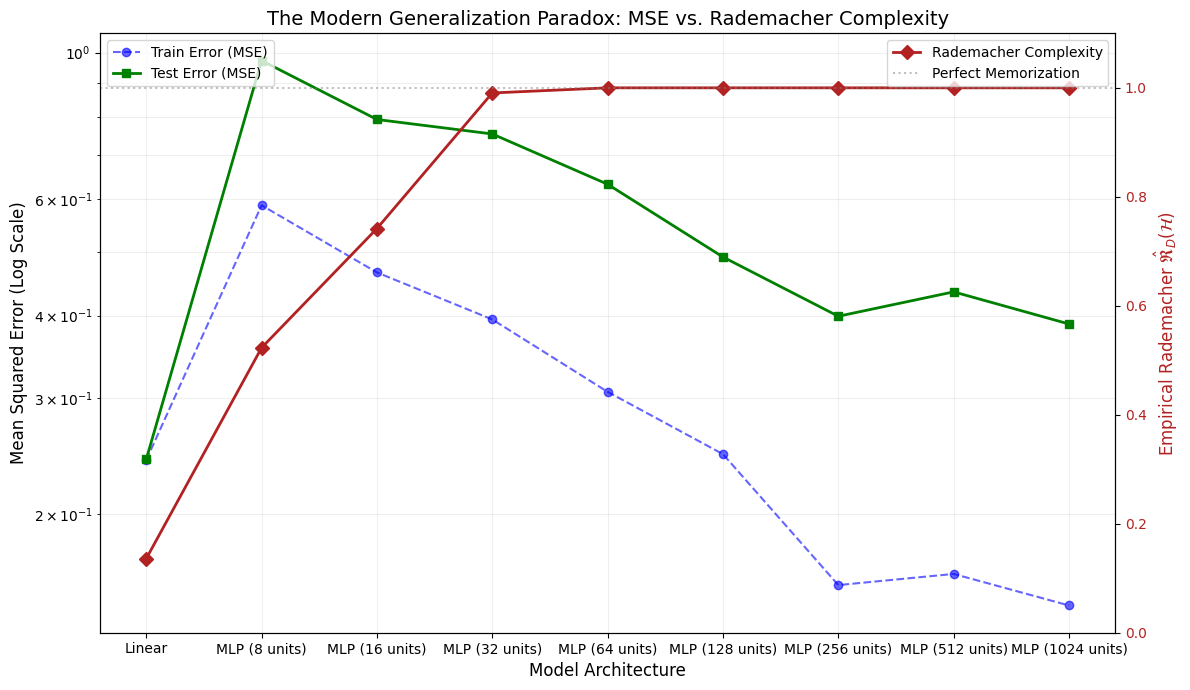

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Primo Asse Y: Errore MSE (Log Scale) ---
ax1.plot(labels_d, train_errors_d, 'o--', label='Train Error (MSE)', color='blue', alpha=0.6)
ax1.plot(labels_d, test_errors_d, 's-', label='Test Error (MSE)', color='green', linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel('Model Architecture', fontsize=12)
ax1.set_ylabel('Mean Squared Error (Log Scale)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_title('The Modern Generalization Paradox: MSE vs. Rademacher Complexity', fontsize=14)
ax1.legend(loc='upper left')
ax1.grid(True, which="both", ls="-", alpha=0.2)

# --- Secondo Asse Y: Rademacher Complexity (Linear Scale) ---
ax2 = ax1.twinx()  # Crea l'asse a destra
ax2.plot(labels_d, rad_results, 'D-', label='Rademacher Complexity', color='firebrick', linewidth=2, markersize=7)
ax2.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5, label='Perfect Memorization')

ax2.set_ylabel('Empirical Rademacher $\hat{\mathfrak{R}}_D(\mathcal{H})$', color='firebrick', fontsize=12)
ax2.tick_params(axis='y', labelcolor='firebrick')
ax2.set_ylim(0, 1.1) # La complessità va da 0 a 1
ax2.legend(loc='upper right')

plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

## Reconciling Theory: The Double Descent Phenomenon
If Deep NNs can memorize noise, why do they generalize?

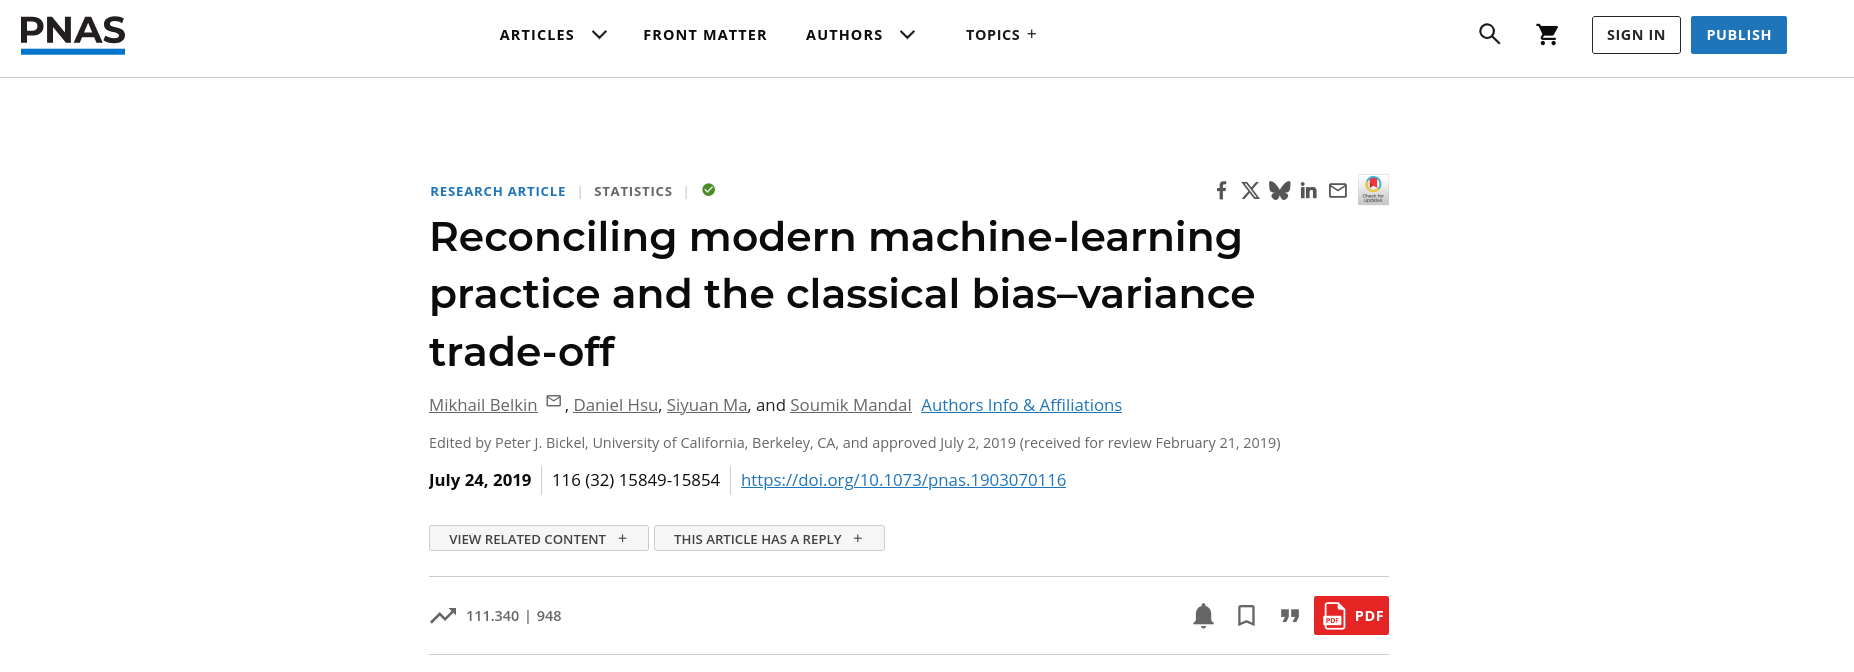

> *“Breakthroughs in machine learning are rapidly changing science and society, yet our fundamental understanding of this technology has lagged far behind. Indeed, one of the central tenets of the field, the bias–variance trade-off, **appears to be at odds** with the observed behavior of methods used in modern machine-learning practice. The bias–variance trade-off implies that a model should balance underfitting and overfitting: rich enough to express underlying structure in data and simple enough to avoid fitting spurious patterns. However, in modern practice, **very rich models such as neural networks are trained to exactly fit (i.e., interpolate) the data**. Classically, such models would be considered overfitted, and yet they often obtain high accuracy on test data. This **apparent contradiction** has raised questions about the mathematical foundations of machine learning and their relevance to practitioners. In this paper, we **reconcile the classical understanding and the modern practice within a unified performance curve**. This **‘double-descent’ curve** subsumes the textbook U-shaped bias–variance trade-off curve by showing how increasing model capacity beyond the point of interpolation results in improved performance. We provide evidence for the existence and ubiquity of double descent for a wide spectrum of models and datasets, and we posit a mechanism for its emergence. This connection between the performance and the structure of machine-learning models delineates the limits of classical analyses and has implications for both the theory and the practice of machine learning.”*  
> — Belkin, Hsu, Ma & Mandal (2019), *Reconciling modern machine learning practice and the bias–variance trade-off*, PNAS.

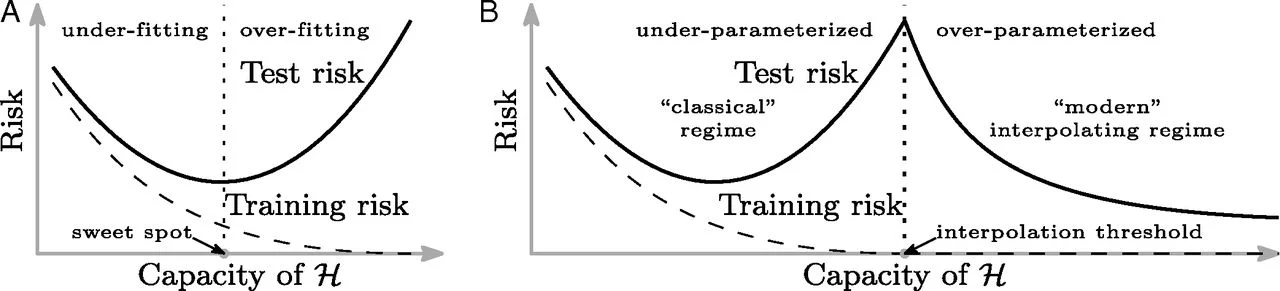

Today we will attempt to recreate this phenomenon. As you can see from the figures here, the x-axis represents the **capacity** of $\mathcal{H}$, that we have previously rephrased as *number of neurons* of a MLP regressor. On the y-axis instead we want to track the error (both train and test errors).

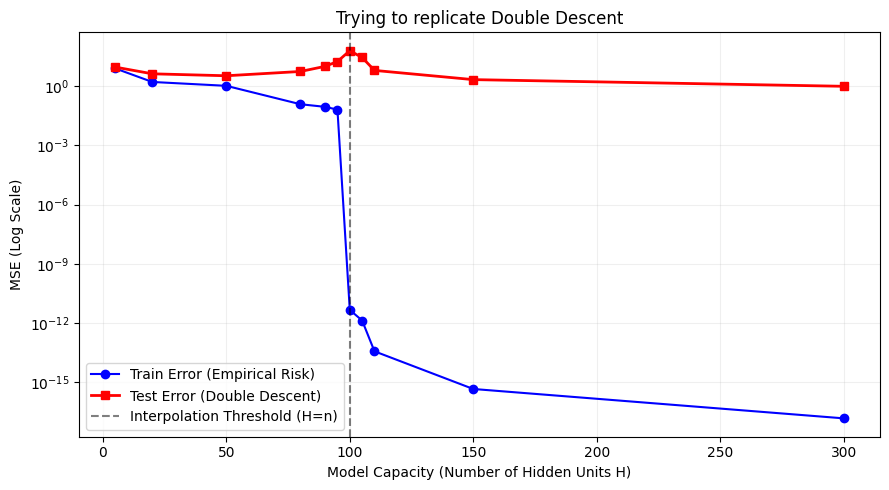

In [13]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Setup: n_samples must be fixed to clearly see the interpolation threshold
np.random.seed(42)
n_samples = 100
n_features = 20

X_train_dd = np.random.randn(n_samples, n_features)
X_test_dd = np.random.randn(500, n_features) # Large test set for stability
true_w = np.random.randn(n_features)

# Generate y with a little bit of noise
y_train_dd = X_train_dd.dot(true_w) + np.random.normal(0, 0.5, size=n_samples)
y_test_dd = X_test_dd.dot(true_w) + np.random.normal(0, 0.5, size=500)

# 2. Capacity (H): number of randomly projected features
# We step through the threshold of 100 (number of training samples)
capacities = [5, 20, 50, 80, 90, 95, 100, 105, 110, 150, 300]
train_errs, test_errs = [], []

for H in capacities:
    np.random.seed(42) # Keep seed inside loop for consistency across runs
    
    # TODO 1: Create the random projection matrix (Random Kitchen Sinks).
    # Generate a weight matrix 'W_rand' of shape (n_features, H) sampled from a standard normal distribution.
    # Hint: np.random.randn(...)
    W_rand = np.random.randn(n_features, H)
    
    # TODO 2: Apply the non-linear transformation (ReLU).
    # Perform matrix multiplication between X_train_dd and W_rand, then apply the ReLU function (max(0, x)).
    # Do the exact same for X_test_dd.
    # Hint: np.maximum(0, ...) and the .dot() method or @ operator.
    Z_train = np.maximum(0, X_train_dd @ W_rand)
    Z_test = np.maximum(0, X_test_dd @ W_rand)
    
    # TODO 3: Initialize and train the Ridge regression model.
    # REGULARIZATION: A tiny alpha is the key to seeing the descent after the peak!
    # If alpha is too high, the peak disappears. If it's 0 (LinearRegression), the peak goes to infinity.
    # Fit a Ridge model with alpha=1e-6 on the transformed training data (Z_train, y_train_dd).
    model = Ridge(alpha=1e-6)
    model.fit(Z_train, y_train_dd)
    
    # TODO 4: Calculate the Mean Squared Error for both train and test sets.
    # Use the trained model to predict on Z_train and Z_test.
    # Append the results to 'train_errs' and 'test_errs'.
    tr_err = mean_squared_error(y_train_dd, model.predict(Z_train))
    te_err = mean_squared_error(y_test_dd, model.predict(Z_test))
    train_errs.append(tr_err)
    test_errs.append(te_err)

    # REPLACE THESE lines with your appended calculations once TODOs 1-4 are done:
    # train_errs.append(...)
    # test_errs.append(...)
    pass 

# ---------------------------------------------------------
# 3. Plotting (Do not modify this part)
# ---------------------------------------------------------
if len(train_errs) == len(capacities): # Checks if the loop was completed
    plt.figure(figsize=(9, 5))
    plt.plot(capacities, train_errs, 'b-o', label='Train Error (Empirical Risk)')
    plt.plot(capacities, test_errs, 'r-s', label='Test Error (Double Descent)', linewidth=2)

    # Vertical line at the interpolation threshold (H = n_samples)
    plt.axvline(x=n_samples, color='black', linestyle='--', alpha=0.5, label='Interpolation Threshold (H=n)')

    plt.yscale('log') # Crucial to clearly see both the peak and the descent
    plt.xlabel('Model Capacity (Number of Hidden Units H)')
    plt.ylabel('MSE (Log Scale)')
    plt.title('Trying to replicate Double Descent')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Complete the TODOs inside the loop to see the plot!")

## The Scaling Laws

As we saw with the Double Descent, once a model enters the highly over-parameterized regime, adding more capacity doesn't cause overfitting; instead, it improves generalization. But **how much** does it improve?

Turns out, the improvement is remarkably **predictable**. 
Empirical research has shown that the test loss $L$ decays as a power law with respect to the three main bottlenecks of machine learning: 
- Compute ($C$), 
- Dataset Size ($D$),
- Number of Parameters ($N$).

$$L(X) \propto X^{-\alpha}$$

Where $X$ can be $N$, $D$, or $C$, and $\alpha$ is a scaling exponent. On a Log-Log plot, this power law appears as a straight line.

**Key Contributions:**
- Hestness et al. (2017) - "Deep Learning Scaling is Predictable, Empirically": As you noted, a "pre-GPT" pioneer paper that demonstrated power-law scaling across multiple domains (vision, speech, translation).
- Kaplan et al. (2020) - "Scaling Laws for Neural Language Models": The seminal OpenAI paper that laid the foundation for GPT-3. They proved that performance depends strongly on scale ($N$, $D$, $C$) and very weakly on architectural hyper-parameters (like depth vs. width).
- Rae et al. (2021) - "Scaling Language Models: Methods, Analysis & Insights from Training Gopher": DeepMind trained a 280-billion parameter model to push the limits of Kaplan's laws. They discovered that while overall loss scales predictably, performance on specific downstream tasks (like logical reasoning or math) can be unpredictable, sometimes exhibiting sudden "emergent" capabilities at massive scales.
- Hoffmann et al. (2022) - "Training Compute-Optimal Large Language Models": The famous "Chinchilla" paper by DeepMind. They updated Kaplan's laws, showing that to train optimally, you must scale model size ($N$) and dataset size ($D$) proportionally. If you 10x your parameters, you should 10x your training data!

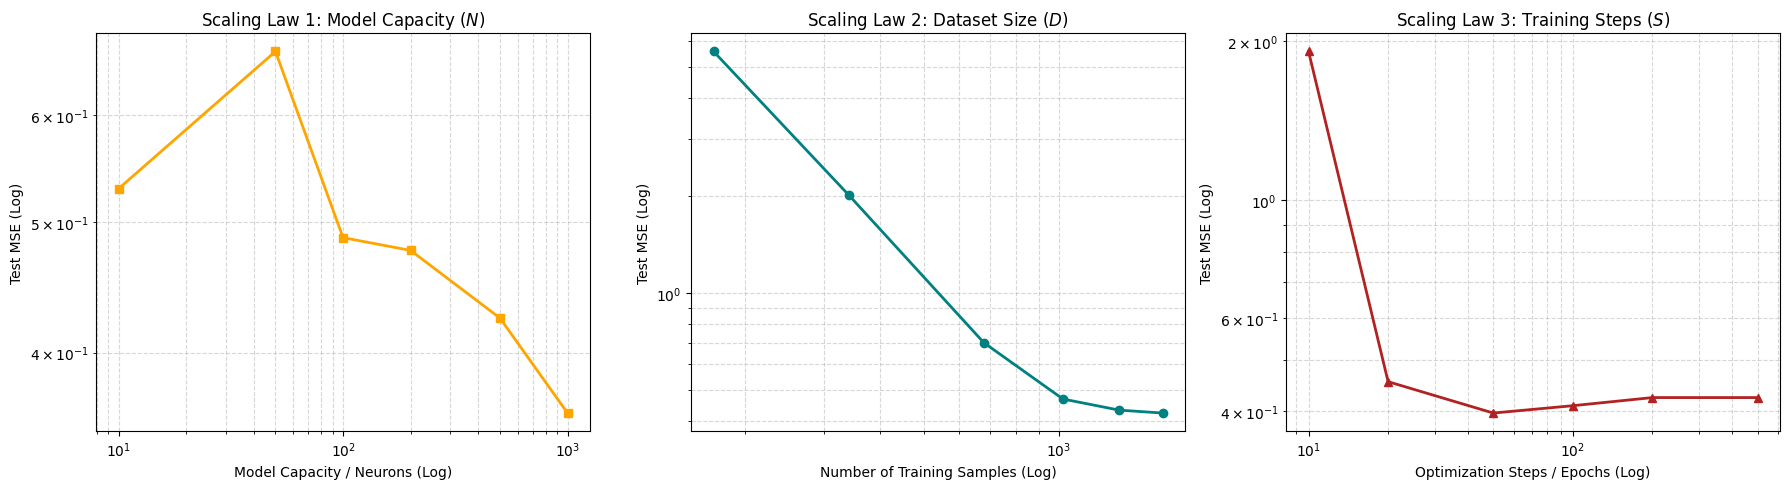

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Assuming we have a large dataset generated previously:
# X_train, y_train, X_test, y_test

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# =====================================================================
# Experiment 1: Scaling Model Capacity (Parameters N)
# Fix the data and the epochs, exponentially increase the neurons
# =====================================================================
widths = [10, 50, 100, 200, 500, 1000]
width_test_errs = []

for w in widths:
    # TODO 1: Initialize the MLPRegressor to scale capacity.
    # Set hidden_layer_sizes to (w,), fix max_iter to 500, and use random_state=42.
    model_n = MLPRegressor(hidden_layer_sizes=(w,), max_iter=500, random_state=42)
    
    # TODO 2: Fit the model on the full training data (X_train, y_train).
    model_n.fit(X_train, y_train)
    
    # TODO 3: Calculate the mean_squared_error on the test set and append it to width_test_errs.
    width_test_errs.append(mean_squared_error(y_test, model_n.predict(X_test)))


# =====================================================================
# Experiment 2: Scaling Dataset Size (Data D)
# Fix a very large network and the epochs, increase the data provided
# =====================================================================
data_fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
data_sizes = [int(f * len(X_train)) for f in data_fractions]
data_test_errs = []

for size in data_sizes:
    # TODO 4: Initialize the MLPRegressor to act as our fixed over-parameterized model.
    # Set hidden_layer_sizes to (500,), fix max_iter to 500, and use random_state=42.
    model_d = MLPRegressor(hidden_layer_sizes=(500,), max_iter=500, random_state=42)
    
    # TODO 5: Fit the model on a SLICE of the training data corresponding to 'size'.
    # Hint: Use X_train[:size] and y_train[:size]
    model_d.fit(X_train[:size], y_train[:size])
    
    
    # TODO 6: Calculate the mean_squared_error on the FULL test set (X_test, y_test) 
    # and append it to data_test_errs.
    data_test_errs.append(mean_squared_error(y_test, model_d.predict(X_test)))


# =====================================================================
# Experiment 3: Scaling Training Steps / Compute (S)
# Fix the large network and the full dataset, increase the epochs
# =====================================================================
steps = [10, 20, 50, 100, 200, 500]
step_test_errs = []

for s in steps:
    # TODO 7: Initialize the MLPRegressor to scale training steps.
    # Set hidden_layer_sizes to (500,), but this time set max_iter to 's'. 
    # Use random_state=42.
    model_s = MLPRegressor(hidden_layer_sizes=(500,), max_iter=s, random_state=42)
    
    # TODO 8: Fit the model on the full training data (X_train, y_train).
    model_s.fit(X_train, y_train)
    
    
    # TODO 9: Calculate the mean_squared_error on the test set and append it to step_test_errs.
    step_test_errs.append(mean_squared_error(y_test, model_s.predict(X_test)))


# ---------------------------------------------------------------------
# Plotting logic (Do not modify)
# ---------------------------------------------------------------------
if len(width_test_errs) == len(widths):
    ax1.plot(widths, width_test_errs, 's-', color='orange', linewidth=2)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_title('Scaling Law 1: Model Capacity ($N$)')
    ax1.set_xlabel('Model Capacity / Neurons (Log)')
    ax1.set_ylabel('Test MSE (Log)')
    ax1.grid(True, which="both", ls="--", alpha=0.5)

if len(data_test_errs) == len(data_sizes):
    ax2.plot(data_sizes, data_test_errs, 'o-', color='teal', linewidth=2)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_title('Scaling Law 2: Dataset Size ($D$)')
    ax2.set_xlabel('Number of Training Samples (Log)')
    ax2.set_ylabel('Test MSE (Log)')
    ax2.grid(True, which="both", ls="--", alpha=0.5)

if len(step_test_errs) == len(steps):
    ax3.plot(steps, step_test_errs, '^-', color='firebrick', linewidth=2)
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.set_title('Scaling Law 3: Training Steps ($S$)')
    ax3.set_xlabel('Optimization Steps / Epochs (Log)')
    ax3.set_ylabel('Test MSE (Log)')
    ax3.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Bonus: Scaling Laws on a Language Model (if you have time and are interested)

As we saw earlier, Kaplan et al. (2020) and Hoffmann et al. (2022) established that the test loss decays as a power law with respect to parameters (N), dataset size (D), and compute (C). While we demonstrated this using simple Multi-Layer Perceptrons, modern scaling laws are almost exclusively studied on autoregressive Language Models predicting the next token.

In this optional challenge, we will use PyTorch to define a `DummyTransformerLM`, a miniature GPT-style architecture. Your goal is to prove the scaling law for Model Capacity (N) by increasing the depth and width of the Transformer and observing how the loss scales on a dummy dataset of synthetic tokens.

Model Configuration                           | Parameters (N)  | Final Loss
---------------------------------------------------------------------------
{'d_model': 16, 'nhead': 2, 'num_layers': 1}  | 36,280          | 7.0495
{'d_model': 32, 'nhead': 4, 'num_layers': 2}  | 90,408          | 6.9745
{'d_model': 64, 'nhead': 4, 'num_layers': 4}  | 328,936         | 6.9266
{'d_model': 128, 'nhead': 8, 'num_layers': 6} | 1,446,632       | 6.9323
{'d_model': 256, 'nhead': 8, 'num_layers': 8} | 6,831,080       | 6.9366


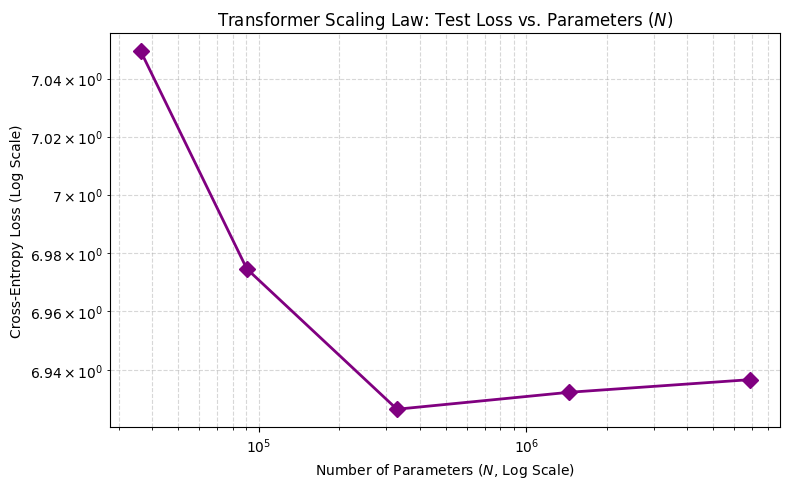

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# 1. The Dummy Transformer Architecture
class DummyTransformerLM(nn.Module):
    def __init__(self, vocab_size=1000, d_model=32, nhead=4, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        # We use a standard Transformer Encoder for simplicity in this dummy task
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        embeds = self.embedding(x)
        out = self.transformer(embeds)
        logits = self.fc_out(out)
        return logits

# 2. Dummy Data Generation (Random sequences of tokens)
def get_dummy_batch(batch_size=32, seq_len=64, vocab_size=1000):
    # Inputs: random integers representing tokens
    X = torch.randint(0, vocab_size, (batch_size, seq_len))
    # Targets: shifted by one (predicting the next token)
    Y = torch.randint(0, vocab_size, (batch_size, seq_len)) 
    return X, Y

# 3. Experimental Setup: Scaling Model Capacity (N)
# We will test 5 different configurations, scaling d_model and num_layers
configs = [
    {'d_model': 16, 'nhead': 2, 'num_layers': 1},   # Tiny
    {'d_model': 32, 'nhead': 4, 'num_layers': 2},   # Small
    {'d_model': 64, 'nhead': 4, 'num_layers': 4},   # Medium
    {'d_model': 128, 'nhead': 8, 'num_layers': 6},  # Large
    {'d_model': 256, 'nhead': 8, 'num_layers': 8},  # XL
]

param_counts = []
final_losses = []

# Shared hyperparameters
vocab_size = 1000
train_steps = 50 

print(f"{'Model Configuration':<45} | {'Parameters (N)':<15} | {'Final Loss':<10}")
print("-" * 75)

for config in configs:
    # TODO 1: Initialize the DummyTransformerLM using the current config and vocab_size.
    model = DummyTransformerLM(vocab_size=vocab_size, **config)
    
    # TODO 2: Calculate the total number of trainable parameters in the model.
    # Hint: sum(p.numel() for p in model.parameters() if p.requires_grad)
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    if num_params is not None:
        param_counts.append(num_params)
    
    # Setup Optimizer and Loss Function
    # NOTE: Leave this intact!
    if model is not None:
        optimizer = optim.AdamW(model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        
        # Training Loop
        model.train()
        for step in range(train_steps):
            X_batch, Y_batch = get_dummy_batch(vocab_size=vocab_size)
            
            optimizer.zero_grad()
            
            # TODO 3: Pass X_batch through the model to get logits
            logits = model(X_batch) 
            
            # TODO 4: Calculate the loss. 
            # Hint: You need to reshape logits to (batch_size * seq_len, vocab_size) 
            # and Y_batch to (batch_size * seq_len) to match PyTorch's CrossEntropyLoss expected inputs.
            loss = criterion(logits.view(-1, vocab_size), Y_batch.view(-1))
            
            if loss is not None:
                loss.backward()
                optimizer.step()
        
        # Record the final loss
        if loss is not None:
            final_losses.append(loss.item())
            print(f"{str(config):<45} | {num_params:<15,} | {loss.item():.4f}")
        else:
            print(f"{str(config):<45} | NOT IMPLEMENTED")

# 4. Plotting the Transformer Scaling Law
if len(param_counts) == len(configs) and len(final_losses) == len(configs):
    plt.figure(figsize=(8, 5))
    plt.plot(param_counts, final_losses, 'D-', color='purple', linewidth=2, markersize=8)
    plt.xscale('log')
    # Loss is often plotted on a log scale or linear depending on the variance; 
    # Log-Log is standard for scaling laws.
    plt.yscale('log') 
    
    plt.title('Transformer Scaling Law: Test Loss vs. Parameters ($N$)')
    plt.xlabel('Number of Parameters ($N$, Log Scale)')
    plt.ylabel('Cross-Entropy Loss (Log Scale)')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("\nComplete the TODOs to see the Scaling Law plot!")